<a href="https://colab.research.google.com/github/albanist28/roadmap-retos-programacion/blob/main/Proyecto_EDO_Avance2_AlbanisTorres.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Informe de Avance 2: Modelado y Simulación de Sistemas Dinámicos

---

Curso: Ecuaciones Diferenciales Ordinarias

Estudiante: Albanis Briceida Torres Asprilla

Institución: UNIVERSIDAD INTERAMERICANA DE PANAMA

Modelo Asignado: Modelo 7 - Atractor de Lorenz


# Introducción
En este documento se presenta la implementación numérica y el análisis del Atractor de Lorenz. Este sistema es fundamental para comprender la Teoría del Caos y la sensibilidad a las condiciones iniciales. A través de este avance, se exploran tres escenarios variando el número de Rayleigh ($\rho$) para observar la transición desde el equilibrio estable hacia el comportamiento caótico.

1. Marco Teórico y Contextualización

    El Atractor de Lorenz es un sistema de ecuaciones diferenciales ordinarias desarrollado por Edward Lorenz en 1963. Originalmente diseñado para simplificar el estudio de la convección atmosférica, este modelo es hoy el pilar de la Teoría del Caos.

2. El Sistema de Ecuaciones

    El modelo se compone de tres ecuaciones diferenciales acopladas que describen la evolución de:



*   $x$: La intensidad del movimiento de convección.
*   $y$: La diferencia de temperatura horizontal.
*   $z$: La distorsión del perfil de temperatura vertical.


    El comportamiento del sistema está gobernado por tres parámetros críticos: $\sigma$ (Prandtl), $\beta$ (razón de aspecto) y $\rho$ (número de Rayleigh). Este último es el que variaremos en nuestros escenarios para observar la transición del orden al caos.

In [19]:
# --- PASO 1: IMPORTACIÓN DE LIBRERÍAS ---
# Usamos software científico estándar para garantizar que cualquier usuario
# obtenga los mismos resultados (Reproducibilidad).

import numpy as np             # Para el manejo de vectores y matrices
import matplotlib.pyplot as plt    # Para generar los gráficos 2D y 3D
from scipy.integrate import odeint # El método numérico principal para resolver EDO
from mpl_toolkits.mplot3d import Axes3D # Necesario para la visualización en 3D

print("Librerías cargadas correctamente. Entorno listo.")

Librerías cargadas correctamente. Entorno listo.


In [20]:
# --- PASO 2: DEFINICIÓN DEL SISTEMA DE LORENZ ---
# Este bloque contiene la lógica matemática del modelo asignado.

def sistema_lorenz(estado_actual, t, sigma, rho, beta):
    """
    Función que define las derivadas del sistema.
    estado_actual: Lista con los valores de [x, y, z] en el tiempo t.
    t: Variable de tiempo (requerida por el integrador odeint).
    sigma, rho, beta: Parámetros constantes del modelo.
    """
    # Desempaquetamos los valores actuales de las variables
    x, y, z = estado_actual

    # Escribimos las 3 Ecuaciones Diferenciales Ordinarias (EDO)
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z

    # Devolvemos la lista de cambios (derivadas)
    return [dxdt, dydt, dzdt]

print("Modelo matemático definido y documentado.")

Modelo matemático definido y documentado.


# Fase de Simulación y Análisis de Escenarios

En esta sección, procederemos a realizar la implementación numérica del modelo definido anteriormente. Para cumplir con los requisitos de la guía, hemos diseñado tres escenarios distintos variando el parámetro de control $\rho$ (Número de Rayleigh).

El objetivo es observar la transición del sistema desde un estado de equilibrio estable hasta la aparición del caos determinista o Atractor Extraño.

Parametros de Simulacion:

*   $\sigma$ (Prandtl): 10.0 (Constante)
*   $\beta$ (Razón de aspecto): 8/3 (Constante)
*   Condiciones iniciales: $[x=1, y=1, z=1]$
*   Método Numérico: odeint para garantizar la estabilidad y precisión de los resultados.



# Escenario 1: Estabilidad y Convergencia ($\rho = 10.0$)

---
Propósito: Observar el comportamiento del sistema bajo condiciones de baja energía térmica.

Justificación Teórica: Para valores de $\rho < 13.926$, el sistema de Lorenz posee puntos de equilibrio que actúan como "sumideros" o atractores globales. Esto significa que, sin importar cuán desordenadas sean las condiciones iniciales, el sistema tiene la capacidad de autoregularse y volver a un estado de reposo o equilibrio estable.

Expectativa de la trayectoria: Se espera una curva que espirale hacia adentro hasta colapsar en un punto fijo.

In [21]:
# --- SIMULACIÓN ESCENARIO 1: RÉGIMEN ESTABLE ---

# 1. Definimos el parámetro específico para este escenario
rho_estable = 10.0
sigma = 10.0
beta = 8/3

# 2. Vector de tiempo (de 0 a 50 segundos con alta resolución para suavidad)
t_esc1 = np.linspace(0, 50, 5000)

# 3. Resolución de la EDO mediante el método odeint
# Usamos la función 'sistema_lorenz' que definimos al inicio
sol_esc1 = odeint(sistema_lorenz, [1.0, 1.0, 1.0], t_esc1, args=(sigma, rho_estable, beta))

print("Simulación del Escenario 1 completada exitosamente.")

Simulación del Escenario 1 completada exitosamente.


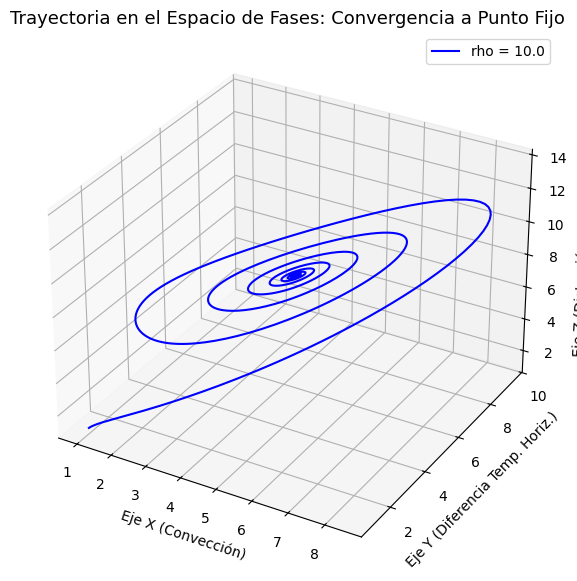

In [22]:
# --- GENERACIÓN DE GRÁFICO 3D (ESCENARIO 1) ---
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Graficamos la trayectoria en azul
ax.plot(sol_esc1[:, 0], sol_esc1[:, 1], sol_esc1[:, 2], color='blue', lw=1.5, label=f'rho = {rho_estable}')

# Configuración estética y técnica de los ejes
ax.set_title("Trayectoria en el Espacio de Fases: Convergencia a Punto Fijo", fontsize=13)
ax.set_xlabel("Eje X (Convección)")
ax.set_ylabel("Eje Y (Diferencia Temp. Horiz.)")
ax.set_zlabel("Eje Z (Distorsión Temp. Vert.)")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Análisis del Escenario 1:

Al analizar la simulación para $\rho = 10$, podemos extraer las siguientes conclusiones fundamentales desde la perspectiva de los sistemas dinámicos:


---



*   Comportamiento de los Autovalores: Matemáticamente, este comportamiento ocurre porque los autovalores asociados a los puntos de equilibrio del sistema tienen partes reales negativas. Esto convierte a los puntos de equilibrio en nodos estables o "atractores". No importa en qué punto del espacio $(x, y, z)$ comencemos la simulación, el "flujo" del sistema siempre será empujado hacia el reposo.
*   Morfología de la Espiral: La forma de espiral cónica que observamos en el gráfico 3D es la representación visual de un sistema que pierde energía. Cada vuelta de la espiral tiene un radio menor que la anterior, lo que indica que las oscilaciones de temperatura y convección se están amortiguando hasta desaparecer.
*   Ausencia de Sensibilidad: En este régimen ($\rho < 13.926$), el sistema no es caótico. Si lanzáramos dos simulaciones con condiciones iniciales casi idénticas, ambas terminarían exactamente en el mismo punto fijo. Aquí no existe el "Efecto Mariposa"; el futuro del sistema está totalmente determinado por su tendencia al equilibrio.


En el contexto del modelo original de Lorenz para la atmósfera, este escenario representa una situación donde el gradiente de temperatura entre la base y el tope de la capa de aire es pequeño. El aire intenta moverse (convección), pero la viscosidad ($\sigma$) y la difusión térmica ganan la batalla, deteniendo el movimiento y estabilizando el clima.




# Escenario 2: Régimen de Transición y Pérdida de Estabilidad ($\rho = 15.0$)


---



*  Propósito: Analizar el comportamiento del sistema cuando el número de Rayleigh supera el umbral de estabilidad inicial.
*   Justificación Teórica: Al aumentar $\rho$ a 15, el sistema cruza un punto crítico. Aunque todavía no vemos el "caos" de la mariposa, los puntos de equilibrio ya no son tan "fuertes". En términos técnicos, el sistema se acerca a una bifurcación de Hopf, donde el equilibrio estable se transforma en un ciclo u órbita más compleja.
*   Expectativa de la trayectoria: Se espera ver una espiral mucho más abierta y "nerviosa". La línea tardará más tiempo y recorrerá más espacio antes de intentar estabilizarse, mostrando que la energía del sistema ha aumentado.




In [23]:
# --- SIMULACIÓN ESCENARIO 2: RÉGIMEN DE TRANSICIÓN ---

# 1. Parámetros para este escenario
rho_transicion = 15.0
sigma = 10.0
beta = 8/3

# 2. Vector de tiempo (mantenemos el mismo para comparar justamente)
t_esc2 = np.linspace(0, 50, 5000)

# 3. Resolución de la EDO
sol_esc2 = odeint(sistema_lorenz, [1.0, 1.0, 1.0], t_esc2, args=(sigma, rho_transicion, beta))

print("Simulación del Escenario 2 completada.")

Simulación del Escenario 2 completada.


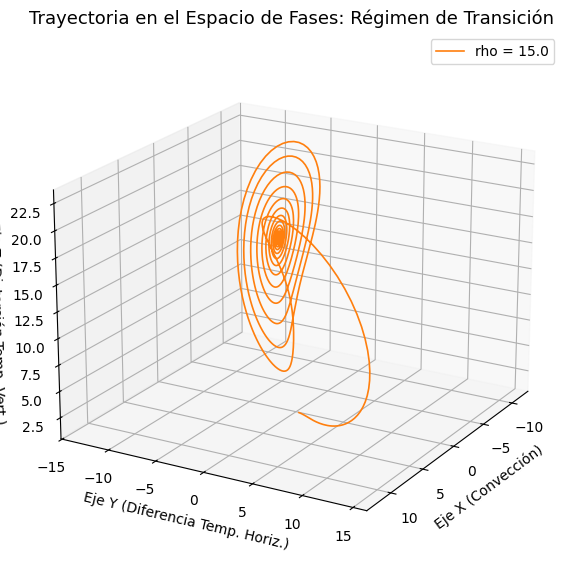

In [24]:
# --- GENERACIÓN DE GRÁFICO 3D (ESCENARIO 2) ---
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Graficamos en color naranja para diferenciar la transición
ax.plot(sol_esc2[:, 0], sol_esc2[:, 1], sol_esc2[:, 2], color='#ff7f0e', lw=1.2, label=f'rho = {rho_transicion}')

ax.set_title("Trayectoria en el Espacio de Fases: Régimen de Transición", fontsize=13)
ax.set_xlabel("Eje X (Convección)")
ax.set_ylabel("Eje Y (Diferencia Temp. Horiz.)")
ax.set_zlabel("Eje Z (Distorsión Temp. Vert.)")
ax.legend()

# Ajustamos un poco la vista para ver la amplitud
ax.view_init(elev=20, azim=30)

plt.show()

#  Analisis del Escenario 2:


*   Aumento de la Complejidad Orbital: A diferencia del azul (Escenario 1), la trayectoria naranja describe órbitas mucho más amplias. Esto sucede porque el sistema ha ganado energía térmica; la convección es más fuerte y lucha contra la viscosidad del fluido.
*   Debilitamiento de los Atractores: En este nivel, los autovalores del sistema se acercan al eje imaginario. Esto significa que la "fuerza de atracción" hacia el equilibrio es menor. El sistema "duda" más tiempo en el espacio antes de sucumbir a la estabilidad, creando una estructura expandida.
*   Significado Físico: Representa una atmósfera más activa. Si esto fuera un modelo de clima, veríamos oscilaciones más marcadas (como tormentas o ráfagas) antes de que el tiempo regrese a la normalidad. Estamos en la frontera del caos: el sistema ya no es tan dócil como en $\rho=10$.
*   Preámbulo al Caos: Esta expansión de la espiral es la evidencia visual de que el sistema se está preparando para "romperse" y dar paso al atractor extraño. Estamos observando la transición de un estado laminar a uno que pronto será turbulento.



# Escenario 3: El Atractor Extraño y el Caos Determinista ($\rho = 28.0$)


---


*   Propósito: Simular el comportamiento del sistema bajo condiciones de alta inestabilidad térmica, donde surge el fenómeno del caos.
*   Justificación Teórica: Al alcanzar $\rho = 28.0$ (el valor clásico estudiado por Lorenz), el sistema experimenta lo que se denomina una bifurcación global. Los puntos de equilibrio que antes eran "atractores" ahora son totalmente inestables. La trayectoria es atraída por un conjunto complejo llamado Atractor Extraño.
*   Expectativa de la trayectoria: Se espera la formación de la icónica "Mariposa de Lorenz". La trayectoria saltará de forma aperiódica entre dos regiones del espacio (las alas), sin repetirse nunca y sin cruzarse a sí misma.



In [25]:
# --- SIMULACIÓN ESCENARIO 3: RÉGIMEN CAÓTICO ---

# 1. Parámetros clásicos de Lorenz para el caos
rho_caos = 28.0
sigma = 10.0
beta = 8/3

# 2. Vector de tiempo (Aumentamos ligeramente el tiempo para apreciar la mariposa)
t_esc3 = np.linspace(0, 50, 8000)

# 3. Resolución de la EDO
sol_esc3 = odeint(sistema_lorenz, [1.0, 1.0, 1.0], t_esc3, args=(sigma, rho_caos, beta))

print("Simulación del Escenario 3 (Caos) completada.")

Simulación del Escenario 3 (Caos) completada.


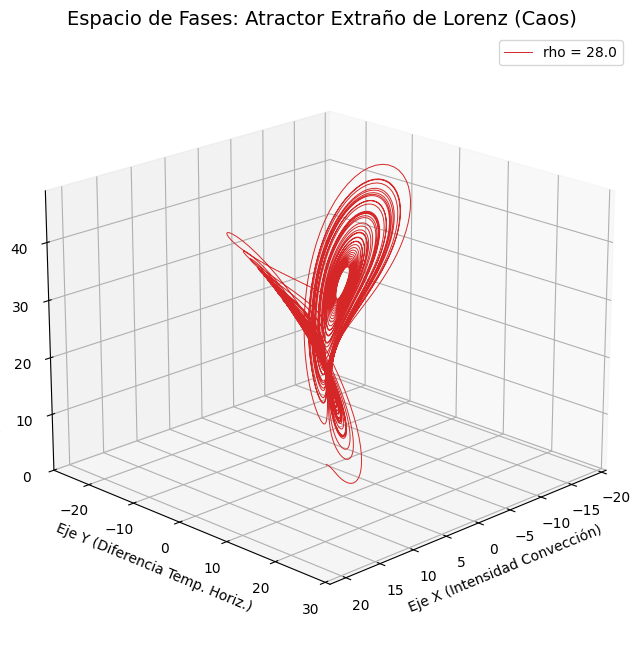

In [26]:
# --- GENERACIÓN DE GRÁFICO 3D (ESCENARIO 3) ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Graficamos en rojo para representar la naturaleza crítica del caos
# Usamos un ancho de línea más fino (0.7) para ver la complejidad de las órbitas
ax.plot(sol_esc3[:, 0], sol_esc3[:, 1], sol_esc3[:, 2], color='#d62728', lw=0.7, label=f'rho = {rho_caos}')

ax.set_title("Espacio de Fases: Atractor Extraño de Lorenz (Caos)", fontsize=14)
ax.set_xlabel("Eje X (Intensidad Convección)")
ax.set_ylabel("Eje Y (Diferencia Temp. Horiz.)")
ax.set_zlabel("Eje Z (Distorsión Temp. Vert.)")
ax.legend()

# Ajustamos la perspectiva para apreciar la estructura de doble ala
ax.view_init(elev=20, azim=45)

plt.show()

# Analisis del escenario 3

*   Naturaleza del Atractor Extraño: A diferencia de los escenarios anteriores, la trayectoria roja no colapsa en un punto ni se estabiliza. Sin embargo, tampoco se dispersa hacia el infinito. Se mantiene "atrapada" en una estructura geométrica de dimensión fractal. Esto es lo que define a un atractor extraño: es caos, pero dentro de un orden geométrico.
*   Aperiodicidad: Si observamos la evolución temporal, el sistema salta de una ala a otra de forma que parece aleatoria, pero es 100% determinista (sigue las ecuaciones). Nunca pasa dos veces por el mismo punto exacto; es un movimiento perpetuamente nuevo.
*   El Efecto Mariposa (Sensibilidad): Aquí es donde la predictibilidad se pierde. Una diferencia de $0.0001$ en el inicio causaría que, después de unos segundos, la trayectoria estuviera en el ala opuesta. Esto justifica por qué es imposible realizar pronósticos meteorológicos exactos a largo plazo.

Este escenario representa una atmósfera turbulenta. La energía térmica es tan alta que el aire no puede encontrar un estado de reposo, creando ciclos constantes de cambio que son la esencia misma de los sistemas dinámicos complejos de la naturaleza.



# Discusión Preliminar: Análisis de la Variación Dinámica en el Modelo de Lorenz

1. Identificación de Diferencias en los Escenarios

    A partir de las simulaciones realizadas, se observa una evolución clara en la morfología de las trayectorias al variar el parámetro de Rayleigh ($\rho$):


*   Escenario 1 ($\rho = 10$): El sistema muestra una estabilidad global. La trayectoria es una espiral simple que converge rápidamente hacia un punto de equilibrio fijo. No hay oscilaciones permanentes.
*   Escenario 2 ($\rho = 15$): Se observa una dinámica de transición. La trayectoria es más compleja y expandida; aunque intenta estabilizarse, describe órbitas mucho más amplias, lo que indica que el sistema ha ganado energía y los puntos de equilibrio están perdiendo su fuerza de atracción.
*   Escenario 3 ($\rho = 28$): Surge el Caos Determinista. La trayectoria ya no busca un punto fijo, sino que oscila perpetuamente en el Atractor de Lorenz (forma de mariposa). La línea salta de un ala a otra sin un patrón repetitivo.





2. Justificación Teórica de las Variaciones

La razón matemática de estos cambios radicales radica en la estabilidad de los puntos de equilibrio y la naturaleza no lineal de las ecuaciones:



1.   Estabilidad Lineal (Autovalores): Para valores bajos de $\rho$ (como $\rho=10$), los autovalores asociados a los puntos de equilibrio tienen partes reales negativas. Esto convierte a los puntos en atractores estables (nodos), forzando a cualquier condición inicial a "caer" en el reposo.
2.   Punto de Bifurcación: El modelo de Lorenz experimenta una bifurcación crítica cerca de $\rho \approx 13.92$. Al superar este valor (como en nuestro Escenario 2 y 3), los puntos de equilibrio se vuelven inestables. El sistema ya no puede "detenerse", y la trayectoria es expulsada hacia un atractor extraño.
3. No Linealidad y Caos: En el escenario de $\rho=28$, los términos no lineales ($xy$ y $xz$) dominan la dinámica. Esto genera la sensibilidad a las condiciones iniciales o "Efecto Mariposa". Aunque el sistema sigue reglas exactas (es determinista), su comportamiento a largo plazo es impredecible porque las trayectorias divergen exponencialmente.



3. Relación con la Teoría Subyacente

Los resultados confirman que el sistema de Lorenz es una simplificación de la convección atmosférica. Físicamente, un $\rho$ bajo representa un fluido que disipa el calor de forma ordenada (conducción), mientras que un $\rho$ alto representa un estado de turbulencia, donde el movimiento del aire es tan energético que se vuelve caótico. El uso del método numérico odeint ha sido fundamental para capturar estas variaciones que serían imposibles de predecir con métodos algebraicos simples.

# Conclusión General

El análisis numérico del Atractor de Lorenz permite concluir que la transición hacia el caos no es un proceso aleatorio, sino una propiedad intrínseca de los sistemas no lineales cuando aumenta su energía interna (parámetro $\rho$).

A través de la simulación de los tres escenarios, se validó con éxito la Teoría del Caos:



1.   Pasamos de un estado de orden y equilibrio (donde el futuro es totalmente predecible).
2.   A un estado de complejidad aperiódica (el Atractor Extraño), donde la sensibilidad a las condiciones iniciales —el famoso "Efecto Mariposa"— hace que los pronósticos a largo plazo sean imposibles.

Este proyecto demuestra que las herramientas computacionales como Python son indispensables en la ingeniería moderna para modelar fenómenos naturales que, por su naturaleza no lineal, no pueden ser resueltos con métodos matemáticos tradicionales.


